In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
import seaborn as sns


In [2]:
# dask
"""import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client"""

'import dask\nimport dask.array as da\nimport distributed\nfrom dask.distributed import Client\n\nclient = Client()\nclient'

In [3]:
#path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
#ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [4]:
#client.close()

In [5]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

"""shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)"""

"shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])\nds_19 = ds_19.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])\nds_22 = ds_22.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])\nds_19_c = ds_19_c.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])\nds_24 = ds_24.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])\nds_1825 = ds_1825.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])\nds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])\nds_1tg = ds_1tg.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_mont

In [6]:
"""lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))"""

'lat = ds_19["lat"]\nweighted_lat = np.cos(np.deg2rad(lat))\nlat_22 = ds_22["lat"]\nweighted_lat_22 = np.cos(np.deg2rad(lat_22))\nlat_19_c = ds_19_c["lat"]\nweighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))\nlat_24 = ds_24["lat"]\nweighted_lat_24 = np.cos(np.deg2rad(lat_24))\nlat_1825 = ds_1825["lat"]\nweighted_lat_1825 = np.cos(np.deg2rad(lat_1825))\nlat_1825_17tg = ds_1825_17tg["lat"]\nweighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))\nlat_1tg = ds_1tg["lat"]\nweighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))\nlat_1pr = ds_1pr["lat"]\nweighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))\nlat_60tg = ds_60tg["lat"]\nweighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))'

In [7]:
lw_top_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FLNT_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in lw_top_19['time'].values])
lw_top_19 = lw_top_19.assign_coords(time=shifted_time_19)
lw_top_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/FLNT_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in lw_top_19_c['time'].values])
lw_top_19_c = lw_top_19_c.assign_coords(time=shifted_time_19_c)
lw_top_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/FLNT_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in lw_top_22['time'].values])
lw_top_22 = lw_top_22.assign_coords(time=shifted_time_22)
lw_top_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/FLNT_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in lw_top_24['time'].values])
lw_top_24 = lw_top_24.assign_coords(time=shifted_time_24)
lw_top_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/FLNT_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in lw_top_1825_17tg['time'].values])
lw_top_1825_17tg = lw_top_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
lw_top_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/FLNT_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in lw_top_1825['time'].values])
lw_top_1825 = lw_top_1825.assign_coords(time=shifted_time_1825)
lw_top_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/FLNT_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in lw_top_1tg['time'].values])
lw_top_1tg = lw_top_1tg.assign_coords(time=shifted_time_1tg)
lw_top_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/FLNT_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in lw_top_1pr['time'].values])
lw_top_1pr = lw_top_1pr.assign_coords(time=shifted_time_1pr)
lw_top_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/FLNT_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in lw_top_60tg['time'].values])
lw_top_60tg = lw_top_60tg.assign_coords(time=shifted_time_60tg)

In [8]:
lat = lw_top_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat = lw_top_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat))
lat = lw_top_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat))
lat = lw_top_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat))
lat = lw_top_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat))
lat = lw_top_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat))
lat = lw_top_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat))
lat = lw_top_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat))
lat = lw_top_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat))

In [9]:
netlwtom = lw_top_19["FLNT"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netlwtom.sel(time=slice("1986-01", "1990-12"))
baseline = baseline.groupby("time.month").mean("time")
netlwtom_anom = -(netlwtom.groupby("time.month") - baseline)
netlwtom_anom = netlwtom_anom.sel(time=slice("1991-01", "1996-01"))

In [10]:
netlwtom_19_c = lw_top_19_c["FLNT"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netlwtom_19_c_anom = -(netlwtom_19_c.groupby("time.month") - baseline)

netlwtom_22 = lw_top_22["FLNT"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netlwtom_22_anom = -(netlwtom_22.groupby("time.month") - baseline)

netlwtom_24 = lw_top_24["FLNT"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netlwtom_24_anom = -(netlwtom_24.groupby("time.month") - baseline)

netlwtom_1825 = lw_top_1825["FLNT"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netlwtom_1825_anom = -(netlwtom_1825.groupby("time.month") - baseline)

netlwtom_1825_17tg = lw_top_1825_17tg["FLNT"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netlwtom_1825_17tg_anom = -(netlwtom_1825_17tg.groupby("time.month") - baseline)

netlwtom_1tg = lw_top_1tg["FLNT"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netlwtom_1tg_anom = -(netlwtom_1tg.groupby("time.month") - baseline)

netlwtom_1pr = lw_top_1pr["FLNT"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netlwtom_1pr_anom = -(netlwtom_1pr.groupby("time.month") - baseline)

netlwtom_60tg = lw_top_60tg["FLNT"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netlwtom_60tg_anom = -(netlwtom_60tg.groupby("time.month") - baseline)

In [11]:
sw_top_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FSNT_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in sw_top_19['time'].values])
sw_top_19 = sw_top_19.assign_coords(time=shifted_time_19)
sw_top_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/FSNT_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in sw_top_19_c['time'].values])
sw_top_19_c = sw_top_19_c.assign_coords(time=shifted_time_19_c)
sw_top_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/FSNT_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in sw_top_22['time'].values])
sw_top_22 = sw_top_22.assign_coords(time=shifted_time_22)
sw_top_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/FSNT_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in sw_top_24['time'].values])
sw_top_24 = sw_top_24.assign_coords(time=shifted_time_24)
sw_top_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/FSNT_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in sw_top_1825_17tg['time'].values])
sw_top_1825_17tg = sw_top_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
sw_top_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/FSNT_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in sw_top_1825['time'].values])
sw_top_1825 = sw_top_1825.assign_coords(time=shifted_time_1825)
sw_top_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/FSNT_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in sw_top_1tg['time'].values])
sw_top_1tg = sw_top_1tg.assign_coords(time=shifted_time_1tg)
sw_top_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/FSNT_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in sw_top_1pr['time'].values])
sw_top_1pr = sw_top_1pr.assign_coords(time=shifted_time_1pr)
sw_top_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/FSNT_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in sw_top_60tg['time'].values])
sw_top_60tg = sw_top_60tg.assign_coords(time=shifted_time_60tg)

In [12]:
netswtom = sw_top_19["FSNT"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netswtom.sel(time=slice("1986-01", "1990-12"))
baseline = baseline.groupby("time.month").mean("time")
netswtom_anom = netswtom.groupby("time.month") - baseline
netswtom_anom = netswtom_anom.sel(time=slice("1991-01", "1996-01"))

In [13]:
netswtom_19_c = sw_top_19_c["FSNT"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netswtom_19_c_anom = netswtom_19_c.groupby("time.month") - baseline

netswtom_22 = sw_top_22["FSNT"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netswtom_22_anom = netswtom_22.groupby("time.month") - baseline

netswtom_24 = sw_top_24["FSNT"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netswtom_24_anom = netswtom_24.groupby("time.month") - baseline

netswtom_1825 = sw_top_1825["FSNT"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netswtom_1825_anom = netswtom_1825.groupby("time.month") - baseline

netswtom_1825_17tg = sw_top_1825_17tg["FSNT"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netswtom_1825_17tg_anom = netswtom_1825_17tg.groupby("time.month") - baseline

netswtom_1tg = sw_top_1tg["FSNT"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netswtom_1tg_anom = netswtom_1tg.groupby("time.month") - baseline

netswtom_1pr = sw_top_1pr["FSNT"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netswtom_1pr_anom = netswtom_1pr.groupby("time.month") - baseline

netswtom_60tg = sw_top_60tg["FSNT"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netswtom_60tg_anom = netswtom_60tg.groupby("time.month") - baseline

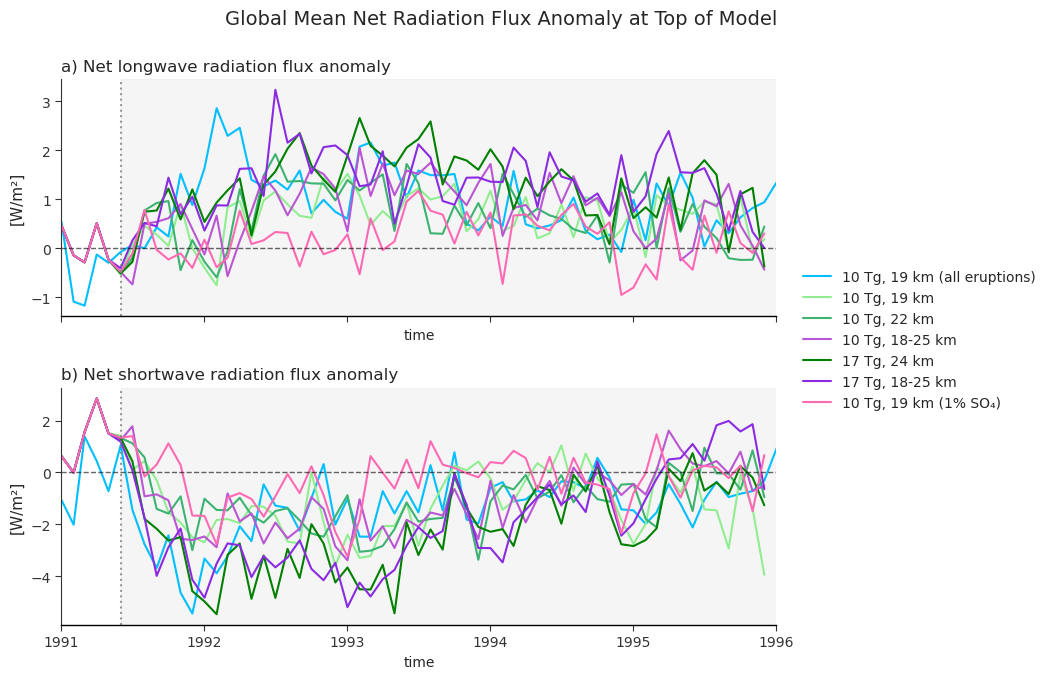

In [14]:
sns.set_style("ticks")
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
start_date    = cftime.DatetimeNoLeap(1991, 1, 1)
end_date      = cftime.DatetimeNoLeap(1996, 1, 1)

xticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in range(1991, 1997)]
xtick_labels = [str(y) for y in range(1991, 1997)]

fig, (ax_lw, ax_sw) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

netlwtom_anom.plot(ax=ax_lw, color="deepskyblue", lw=1.5, label="10 Tg, 19 km (all eruptions)")
netlwtom_19_c_anom.plot(ax=ax_lw, color="lightgreen", lw=1.5, label="10 Tg, 19 km")
netlwtom_22_anom.plot(ax=ax_lw, color="mediumseagreen", lw=1.5, label="10 Tg, 22 km")
netlwtom_1825_anom.plot(ax=ax_lw, color="mediumorchid", lw=1.5, label="10 Tg, 18-25 km")
netlwtom_24_anom.plot(ax=ax_lw, color="green", lw=1.5, label="17 Tg, 24 km")
netlwtom_1825_17tg_anom.plot(ax=ax_lw, color="blueviolet", lw=1.5, label="17 Tg, 18-25 km")
netlwtom_1pr_anom.plot(ax=ax_lw, color="hotpink", lw=1.5, label="10 Tg, 19 km (1% SO₄)")
#netlwtom_60tg_anom.plot(ax=ax_lw, color="cornflowerblue", lw=1.5, label="60 Tg, 19 km")

netswtom_anom.plot(ax=ax_sw, color="deepskyblue", lw=1.5)
netswtom_19_c_anom.plot(ax=ax_sw, color="lightgreen", lw=1.5)
netswtom_22_anom.plot(ax=ax_sw, color="mediumseagreen", lw=1.5)
netswtom_1825_anom.plot(ax=ax_sw, color="mediumorchid", lw=1.5)
netswtom_24_anom.plot(ax=ax_sw, color="green", lw=1.5)
netswtom_1825_17tg_anom.plot(ax=ax_sw, color="blueviolet", lw=1.5)
netswtom_1pr_anom.plot(ax=ax_sw, color="hotpink", lw=1.5)
#netswtom_60tg_anom.plot(ax=ax_sw, color="cornflowerblue", lw=1.5)

titles = ["a) Net longwave radiation flux anomaly", "b) Net shortwave radiation flux anomaly"]
axes = [ax_lw, ax_sw]

for i, ax in enumerate(axes):
    ax.axhline(0, color="black", lw=1.0, ls='--', alpha=0.6)
    ax.axvline(eruption_date, color='gray', ls=":", alpha=0.8)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.08, zorder=0)
    
    ax.set_ylabel("[W/m²]", fontsize=11)
    ax.set_title(titles[i], loc='left', fontsize=12)
    ax.tick_params(direction='out', length=4)
    
    ax.set_xlim(start_date, end_date)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    
    sns.despine(ax=ax)
    
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.0)

fig.suptitle("Global Mean Net Radiation Flux Anomaly at Top of Model", fontsize=14)

ax_lw.legend(
    loc="center left",
    bbox_to_anchor=(1.02, -0.1), 
    frameon=False,
    fontsize=10
)

fig.subplots_adjust(right=0.75, left=0.1, bottom=0.1, top=0.88, hspace=0.3)

plt.show()


In [15]:
lw_surf_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FLNS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in lw_surf_19['time'].values])
lw_surf_19 = lw_surf_19.assign_coords(time=shifted_time_19)
lw_surf_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/FLNS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in lw_surf_19_c['time'].values])
lw_surf_19_c = lw_surf_19_c.assign_coords(time=shifted_time_19_c)
lw_surf_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/FLNS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in lw_surf_22['time'].values])
lw_surf_22 = lw_surf_22.assign_coords(time=shifted_time_22)
lw_surf_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/FLNS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in lw_surf_24['time'].values])
lw_surf_24 = lw_surf_24.assign_coords(time=shifted_time_24)
lw_surf_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/FLNS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in lw_surf_1825_17tg['time'].values])
lw_surf_1825_17tg = lw_surf_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
lw_surf_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/FLNS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in lw_surf_1825['time'].values])
lw_surf_1825 = lw_surf_1825.assign_coords(time=shifted_time_1825)
lw_surf_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/FLNS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in lw_surf_1tg['time'].values])
lw_surf_1tg = lw_surf_1tg.assign_coords(time=shifted_time_1tg)
lw_surf_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/FLNS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in lw_surf_1pr['time'].values])
lw_surf_1pr = lw_surf_1pr.assign_coords(time=shifted_time_1pr)
lw_surf_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/FLNS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in lw_surf_60tg['time'].values])
lw_surf_60tg = lw_surf_60tg.assign_coords(time=shifted_time_60tg)

In [16]:
netlwsurf = lw_surf_19["FLNS"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netlwsurf.sel(time=slice("1986-01", "1990-12"))
baseline = baseline.groupby("time.month").mean("time")
netlwsurf_anom = netlwsurf.groupby("time.month") - baseline
netlwsurf_anom = netlwsurf_anom.sel(time=slice("1991-01", "1996-01"))

In [17]:
netlwsurf_19_c = lw_surf_19_c["FLNS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netlwsurf_19_c_anom = netlwsurf_19_c.groupby("time.month") - baseline

netlwsurf_22 = lw_surf_22["FLNS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netlwsurf_22_anom = netlwsurf_22.groupby("time.month") - baseline

netlwsurf_24 = lw_surf_24["FLNS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netlwsurf_24_anom = netlwsurf_24.groupby("time.month") - baseline

netlwsurf_1825 = lw_surf_1825["FLNS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netlwsurf_1825_anom = netlwsurf_1825.groupby("time.month") - baseline

netlwsurf_1825_17tg = lw_surf_1825_17tg["FLNS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netlwsurf_1825_17tg_anom = netlwsurf_1825_17tg.groupby("time.month") - baseline

netlwsurf_1tg = lw_surf_1tg["FLNS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netlwsurf_1tg_anom = netlwsurf_1tg.groupby("time.month") - baseline

netlwsurf_1pr = lw_surf_1pr["FLNS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netlwsurf_1pr_anom = netlwsurf_1pr.groupby("time.month") - baseline

netlwsurf_60tg = lw_surf_60tg["FLNS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netlwsurf_60tg_anom = netlwsurf_60tg.groupby("time.month") - baseline

In [18]:
sw_surf_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/FSNS_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in sw_surf_19['time'].values])
sw_surf_19 = sw_surf_19.assign_coords(time=shifted_time_19)
sw_surf_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/FSNS_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in sw_surf_19_c['time'].values])
sw_surf_19_c = sw_surf_19_c.assign_coords(time=shifted_time_19_c)
sw_surf_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/FSNS_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in sw_surf_22['time'].values])
sw_surf_22 = sw_surf_22.assign_coords(time=shifted_time_22)
sw_surf_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/FSNS_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in sw_surf_24['time'].values])
sw_surf_24 = sw_surf_24.assign_coords(time=shifted_time_24)
sw_surf_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/FSNS_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in sw_surf_1825_17tg['time'].values])
sw_surf_1825_17tg = sw_surf_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
sw_surf_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/FSNS_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in sw_surf_1825['time'].values])
sw_surf_1825 = sw_surf_1825.assign_coords(time=shifted_time_1825)
sw_surf_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/FSNS_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in sw_surf_1tg['time'].values])
sw_surf_1tg = sw_surf_1tg.assign_coords(time=shifted_time_1tg)
sw_surf_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/FSNS_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in sw_surf_1pr['time'].values])
sw_surf_1pr = sw_surf_1pr.assign_coords(time=shifted_time_1pr)
sw_surf_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/FSNS_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in sw_surf_60tg['time'].values])
sw_surf_60tg = sw_surf_60tg.assign_coords(time=shifted_time_60tg)

In [19]:
netswsurf = sw_surf_19["FSNS"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netswsurf.sel(time=slice("1986-01", "1990-12"))
baseline = baseline.groupby("time.month").mean("time")
netswsurf_anom = netswsurf.groupby("time.month") - baseline
netswsurf_anom = netswsurf_anom.sel(time=slice("1991-01", "1996-01"))

In [20]:
netswsurf_19_c = sw_surf_19_c["FSNS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netswsurf_19_c_anom = netswsurf_19_c.groupby("time.month") - baseline

netswsurf_22 = sw_surf_22["FSNS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netswsurf_22_anom = netswsurf_22.groupby("time.month") - baseline

netswsurf_24 = sw_surf_24["FSNS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netswsurf_24_anom = netswsurf_24.groupby("time.month") - baseline

netswsurf_1825 = sw_surf_1825["FSNS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netswsurf_1825_anom = netswsurf_1825.groupby("time.month") - baseline

netswsurf_1825_17tg = sw_surf_1825_17tg["FSNS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netswsurf_1825_17tg_anom = netswsurf_1825_17tg.groupby("time.month") - baseline

netswsurf_1tg = sw_surf_1tg["FSNS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netswsurf_1tg_anom = netswsurf_1tg.groupby("time.month") - baseline

netswsurf_1pr = sw_surf_1pr["FSNS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netswsurf_1pr_anom = netswsurf_1pr.groupby("time.month") - baseline

netswsurf_60tg = sw_surf_60tg["FSNS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netswsurf_60tg_anom = netswsurf_60tg.groupby("time.month") - baseline

/tmp/ipykernel_2551705/493519964.py:65: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.75, left=0.1, bottom=0.1, top=0.88, hspace=0.3)


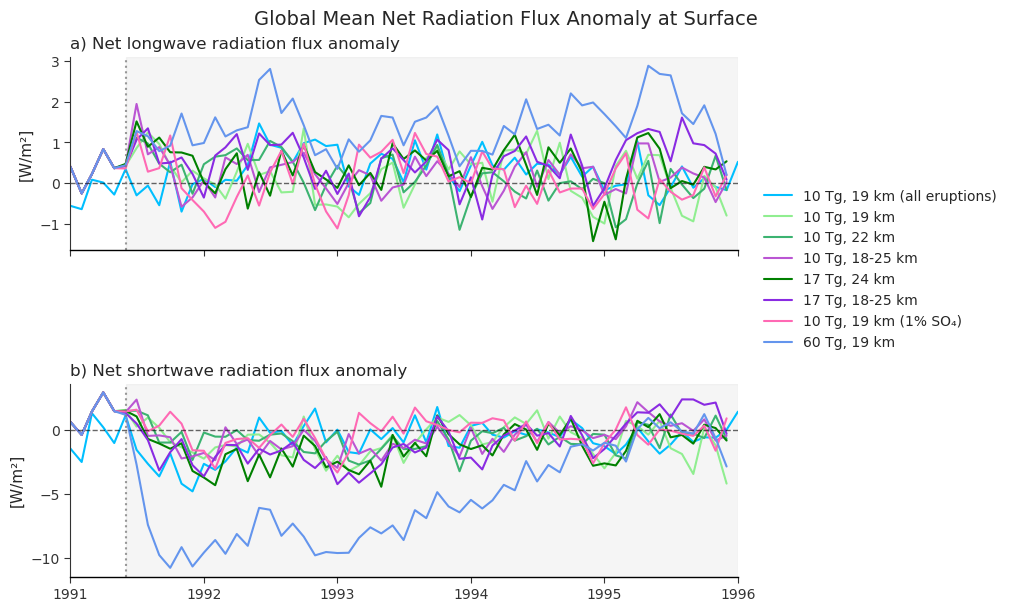

In [21]:
sns.set_style("ticks")
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
start_date    = cftime.DatetimeNoLeap(1991, 1, 1)
end_date      = cftime.DatetimeNoLeap(1996, 1, 1)

xticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in range(1991, 1997)]
xtick_labels = [str(y) for y in range(1991, 1997)]

fig, (ax_lw, ax_sw) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)


ax_lw.plot(netlwsurf_anom.time, netlwsurf_anom, color="deepskyblue", lw=1.5,label="10 Tg, 19 km (all eruptions)")
ax_lw.plot(netlwsurf_19_c_anom.time, netlwsurf_19_c_anom, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax_lw.plot(netlwsurf_22_anom.time, netlwsurf_22_anom,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax_lw.plot(netlwsurf_1825_anom.time, netlwsurf_1825_anom,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax_lw.plot(netlwsurf_24_anom.time, netlwsurf_24_anom,color="green", lw=1.5,label="17 Tg, 24 km")
ax_lw.plot(netlwsurf_1825_17tg_anom.time, netlwsurf_1825_17tg_anom,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax_lw.plot(netlwsurf_1pr_anom.time, netlwsurf_1pr_anom,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax_lw.plot(netlwsurf_60tg_anom.time, netlwsurf_60tg_anom,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax_sw.plot(netswsurf_anom.time, netswsurf_anom,color="deepskyblue", lw=1.5)
ax_sw.plot(netswsurf_19_c_anom.time, netswsurf_19_c_anom,color="lightgreen", lw=1.5)
ax_sw.plot(netswsurf_22_anom.time, netswsurf_22_anom,color="mediumseagreen", lw=1.5)
ax_sw.plot(netswsurf_1825_anom.time, netswsurf_1825_anom,color="mediumorchid", lw=1.5)
ax_sw.plot(netswsurf_24_anom.time, netswsurf_24_anom,color="green", lw=1.5)
ax_sw.plot(netswsurf_1825_17tg_anom.time, netswsurf_1825_17tg_anom,color="blueviolet", lw=1.5)
ax_sw.plot(netswsurf_1pr_anom.time, netswsurf_1pr_anom,color="hotpink", lw=1.5)
ax_sw.plot(netswsurf_60tg_anom.time, netswsurf_60tg_anom,color="cornflowerblue", lw=1.5)

titles = ["a) Net longwave radiation flux anomaly", "b) Net shortwave radiation flux anomaly"]
axes = [ax_lw, ax_sw]

for i, ax in enumerate(axes):
    ax.axhline(0, color="black", lw=1.0, ls='--', alpha=0.6)
    ax.axvline(eruption_date, color='gray', ls=":", alpha=0.8)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.08, zorder=0)
    
    ax.set_ylabel("[W/m²]", fontsize=11)
    ax.set_title(titles[i], loc='left', fontsize=12)
    ax.tick_params(direction='out', length=4)
    
    ax.set_xlim(start_date, end_date)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    
    sns.despine(ax=ax)
    
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.0)

fig.suptitle("Global Mean Net Radiation Flux Anomaly at Surface", fontsize=14)

ax_lw.legend(
    loc="center left",
    bbox_to_anchor=(1.02, -0.1), 
    frameon=False,
    fontsize=10
)

fig.subplots_adjust(right=0.75, left=0.1, bottom=0.1, top=0.88, hspace=0.3)

plt.show()

In [22]:
t_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TREFHT_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in t_19['time'].values])
t_19 = t_19.assign_coords(time=shifted_time_19)
t_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TREFHT_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in t_19_c['time'].values])
t_19_c = t_19_c.assign_coords(time=shifted_time_19_c)
t_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TREFHT_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in t_22['time'].values])
t_22 = t_22.assign_coords(time=shifted_time_22)
t_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TREFHT_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in t_24['time'].values])
t_24 = t_24.assign_coords(time=shifted_time_24)
t_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in t_1825_17tg['time'].values])
t_1825_17tg = t_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
t_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TREFHT_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in t_1825['time'].values])
t_1825 = t_1825.assign_coords(time=shifted_time_1825)
t_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TREFHT_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in t_1tg['time'].values])
t_1tg = t_1tg.assign_coords(time=shifted_time_1tg)
t_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TREFHT_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in t_1pr['time'].values])
t_1pr = t_1pr.assign_coords(time=shifted_time_1pr)
t_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TREFHT_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in t_60tg['time'].values])
t_60tg = t_60tg.assign_coords(time=shifted_time_60tg)

In [23]:
temp_ctrl = t_19["TREFHT"].weighted(weighted_lat).mean(dim=["lat", "lon"]) - 273.15
baseline = temp_ctrl.sel(time=slice("1986-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

temp_19 = temp_ctrl.sel(time=slice("1991-01", "1996-01"))
temp_19_anom = temp_19.groupby("time.month") - base

In [24]:
temp_19_c = t_19_c["TREFHT"].weighted(weighted_lat_19_c).mean(dim = ["lat", "lon"]) -273.15
t_anom_19_c = temp_19_c.groupby("time.month") - base
temp_60tg = t_60tg["TREFHT"].weighted(weighted_lat_60tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_60tg = temp_60tg.groupby("time.month") - base
temp_22 = t_22["TREFHT"].weighted(weighted_lat_22).mean(dim = ["lat", "lon"]) -273.15
t_anom_22 = temp_22.groupby("time.month") - base
temp_24 = t_24["TREFHT"].weighted(weighted_lat_24).mean(dim = ["lat", "lon"]) -273.15
t_anom_24 = temp_24.groupby("time.month") - base
temp_1825 = t_1825["TREFHT"].weighted(weighted_lat_1825).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825 = temp_1825.groupby("time.month") - base
temp_1825_17tg = t_1825_17tg["TREFHT"].weighted(weighted_lat_1825_17tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825_17tg = temp_1825_17tg.groupby("time.month") - base
temp_1tg = t_1tg["TREFHT"].weighted(weighted_lat_1tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1tg = temp_1tg.groupby("time.month") - base
temp_1pr = t_1pr["TREFHT"].weighted(weighted_lat_1pr).mean(dim = ["lat", "lon"]) -273.15
t_anom_1pr = temp_1pr.groupby("time.month") - base

<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2551705/1108003820.py:43: SyntaxWarning: invalid escape sequence '\c'
  ax_t.set_ylabel("[$^\circ$C]")


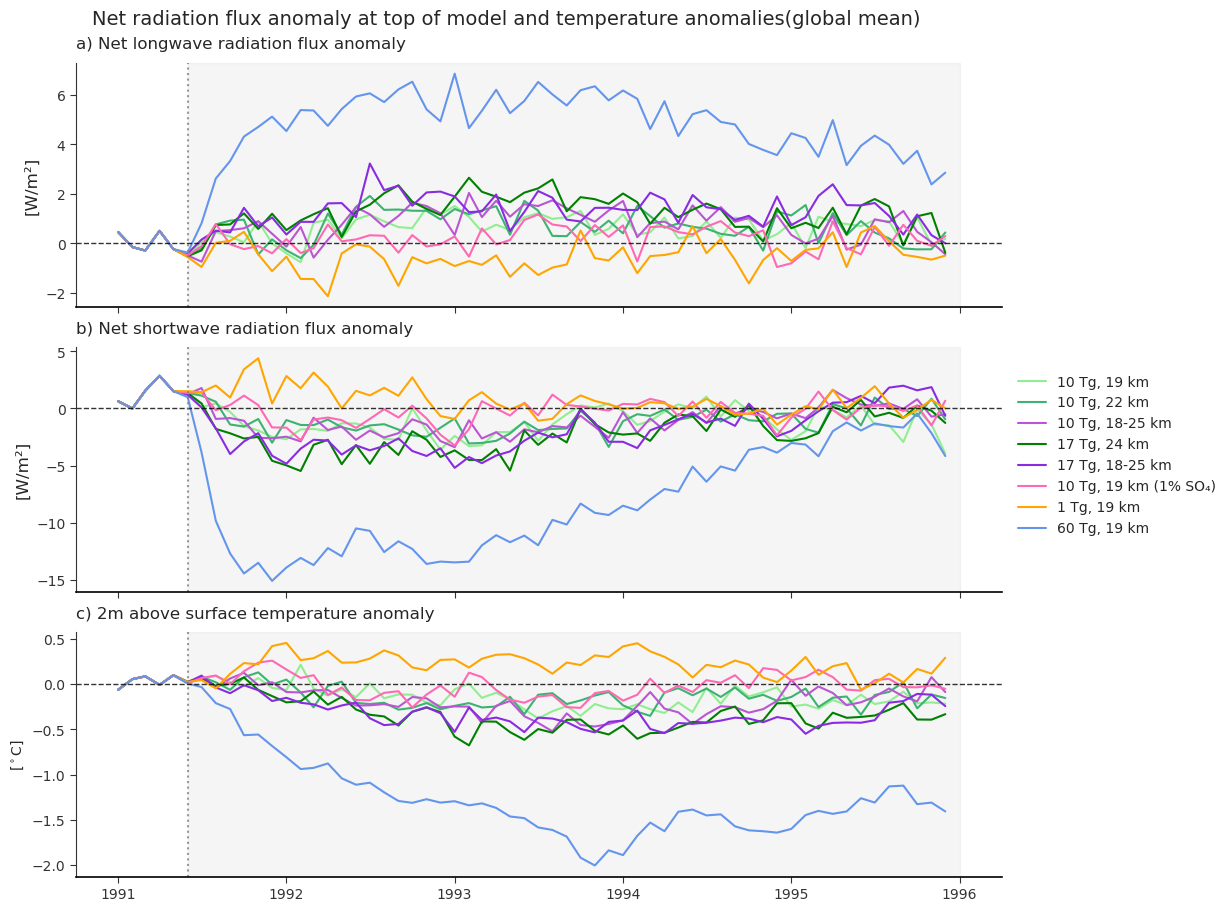

In [26]:
sns.set_style("ticks")
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
start_date    = cftime.DatetimeNoLeap(1991, 1, 1)
end_date      = cftime.DatetimeNoLeap(1996, 1, 1)

xticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in range(1991, 1997)]
xtick_labels = [str(y) for y in range(1991, 1997)]

fig, (ax_lw, ax_sw, ax_t) = plt.subplots(3, 1, figsize=(10, 9), sharex=True, constrained_layout=True)
#ax_lw.plot(netlwtom_19.time, netlwtom_19)
ax_lw.plot(netlwtom_19_c_anom.time, netlwtom_19_c_anom,color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax_lw.plot(netlwtom_22_anom.time, netlwtom_22_anom,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax_lw.plot(netlwtom_1825_anom.time, netlwtom_1825_anom,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax_lw.plot(netlwtom_24_anom.time, netlwtom_24_anom,color="green", lw=1.5,label="17 Tg, 24 km")
ax_lw.plot(netlwtom_1825_17tg_anom.time, netlwtom_1825_17tg_anom,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax_lw.plot(netlwtom_1pr_anom.time, netlwtom_1pr_anom,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax_lw.plot(netlwtom_1tg_anom.time, netlwtom_1tg_anom,color="orange", lw=1.5, label="1 Tg, 19 km")
ax_lw.plot(netlwtom_60tg_anom.time, netlwtom_60tg_anom,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km")
ax_lw.set_ylabel("[W/m²]", fontsize=12)

ax_sw.plot(netswtom_19_c_anom.time, netswtom_19_c_anom,color="lightgreen", lw=1.5)
ax_sw.plot(netswtom_22_anom.time, netswtom_22_anom,color="mediumseagreen", lw=1.5)
ax_sw.plot(netswtom_1825_anom.time, netswtom_1825_anom,color="mediumorchid", lw=1.5)
ax_sw.plot(netswtom_24_anom.time, netswtom_24_anom,color="green", lw=1.5)
ax_sw.plot(netswtom_1825_17tg_anom.time, netswtom_1825_17tg_anom,color="blueviolet", lw=1.5)
ax_sw.plot(netswtom_1pr_anom.time, netswtom_1pr_anom,color="hotpink", lw=1.5)
ax_sw.plot(netswtom_1tg_anom.time, netswtom_1tg_anom,color="orange", lw = 1.5)
ax_sw.plot(netswtom_60tg_anom.time, netswtom_60tg_anom,color="cornflowerblue", lw=1.5)
ax_sw.set_ylabel("[W/m²]", fontsize=12)

ax_t.plot(t_anom_19_c.time, t_anom_19_c,color="lightgreen", lw=1.5)
ax_t.plot(t_anom_22.time, t_anom_22,color="mediumseagreen", lw=1.5)
ax_t.plot(t_anom_1825.time, t_anom_1825,color="mediumorchid", lw=1.5)
ax_t.plot(t_anom_24.time, t_anom_24,color="green", lw=1.5)
ax_t.plot(t_anom_1825_17tg.time, t_anom_1825_17tg,color="blueviolet", lw=1.5)
ax_t.plot(t_anom_1pr.time, t_anom_1pr,color="hotpink", lw=1.5)
ax_t.plot(t_anom_1tg.time, t_anom_1tg, color="orange", lw=1.5)
ax_t.plot(t_anom_60tg.time, t_anom_60tg,color="cornflowerblue", lw=1.5)
ax_t.set_ylabel("[$^\circ$C]")

axes = [ax_lw, ax_sw, ax_t]
titles = ["a) Net longwave radiation flux anomaly", "b) Net shortwave radiation flux anomaly", "c) 2m above surface temperature anomaly"]

for i, ax in enumerate(axes):
    ax.axhline(0, color="black", lw=1.0, ls='--', alpha=0.8)
    ax.axvline(eruption_date, color='gray', ls = ":", alpha=0.8)
    ax.axvspan(eruption_date, cftime.DatetimeNoLeap(1996, 1, 1), color='gray', alpha=0.08, zorder=0)
    ax.tick_params(direction='out', length=4)
    ax.set_title(titles[i], loc='left', fontsize=12, pad=10)
    
    sns.despine(ax=ax)

for ax in [ax_lw, ax_sw, ax_t]:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.2)


fig.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=10
)

plt.suptitle("Net radiation flux anomaly at top of model and temperature anomalies(global mean)", fontsize=14)
plt.show()


In [27]:
total_tom = netswtom - netlwtom
baseline_total = total_tom.sel(time=slice("1986-01", "1990-12")).groupby("time.month").mean("time")

total_tom_19 = (netswtom - netlwtom).groupby("time.month") - baseline_total
total_tom_19 = total_tom_19.sel(time=slice("1991-01", "1996-01"))
total_tom_19_c = (netswtom_19_c - netlwtom_19_c).groupby("time.month") - baseline_total
total_tom_22 = (netswtom_22 - netlwtom_22).groupby("time.month") - baseline_total
total_tom_24 = (netswtom_24 - netlwtom_24).groupby("time.month") - baseline_total
total_tom_1825 = (netswtom_1825 - netlwtom_1825).groupby("time.month") - baseline_total
total_tom_1825_17tg = (netswtom_1825_17tg - netlwtom_1825_17tg).groupby("time.month") - baseline_total
total_tom_1tg = (netswtom_1tg - netlwtom_1tg).groupby("time.month") - baseline_total
total_tom_1pr = (netswtom_1pr - netlwtom_1pr).groupby("time.month") - baseline_total
total_tom_60tg = (netswtom_60tg - netlwtom_60tg).groupby("time.month") - baseline_total

In [28]:
total_surf = netswsurf + netlwsurf
baseline_total = total_surf.sel(time=slice("1986-01", "1990-12")).groupby("time.month").mean("time")

total_surf_19 = (netswsurf + netlwsurf).groupby("time.month") - baseline_total
total_surf_19 = total_surf_19.sel(time=slice("1991-01", "1996-01"))
total_surf_19_c = (netswsurf_19_c + netlwsurf_19_c).groupby("time.month") - baseline_total
total_surf_22 = (netswsurf_22 + netlwsurf_22).groupby("time.month") - baseline_total
total_surf_24 = (netswsurf_24 + netlwsurf_24).groupby("time.month") - baseline_total
total_surf_1825 = (netswsurf_1825 + netlwsurf_1825).groupby("time.month") - baseline_total
total_surf_1825_17tg = (netswsurf_1825_17tg + netlwsurf_1825_17tg).groupby("time.month") - baseline_total
total_surf_1tg = (netswsurf_1tg + netlwsurf_1tg).groupby("time.month") - baseline_total
total_surf_1pr = (netswsurf_1pr + netlwsurf_1pr).groupby("time.month") - baseline_total
total_surf_60tg = (netswsurf_60tg + netlwsurf_60tg).groupby("time.month") - baseline_total

<>:90: SyntaxWarning: invalid escape sequence '\c'
<>:90: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2551705/4162317905.py:90: SyntaxWarning: invalid escape sequence '\c'
  ax_t.set_ylabel("[$^\circ$C]")


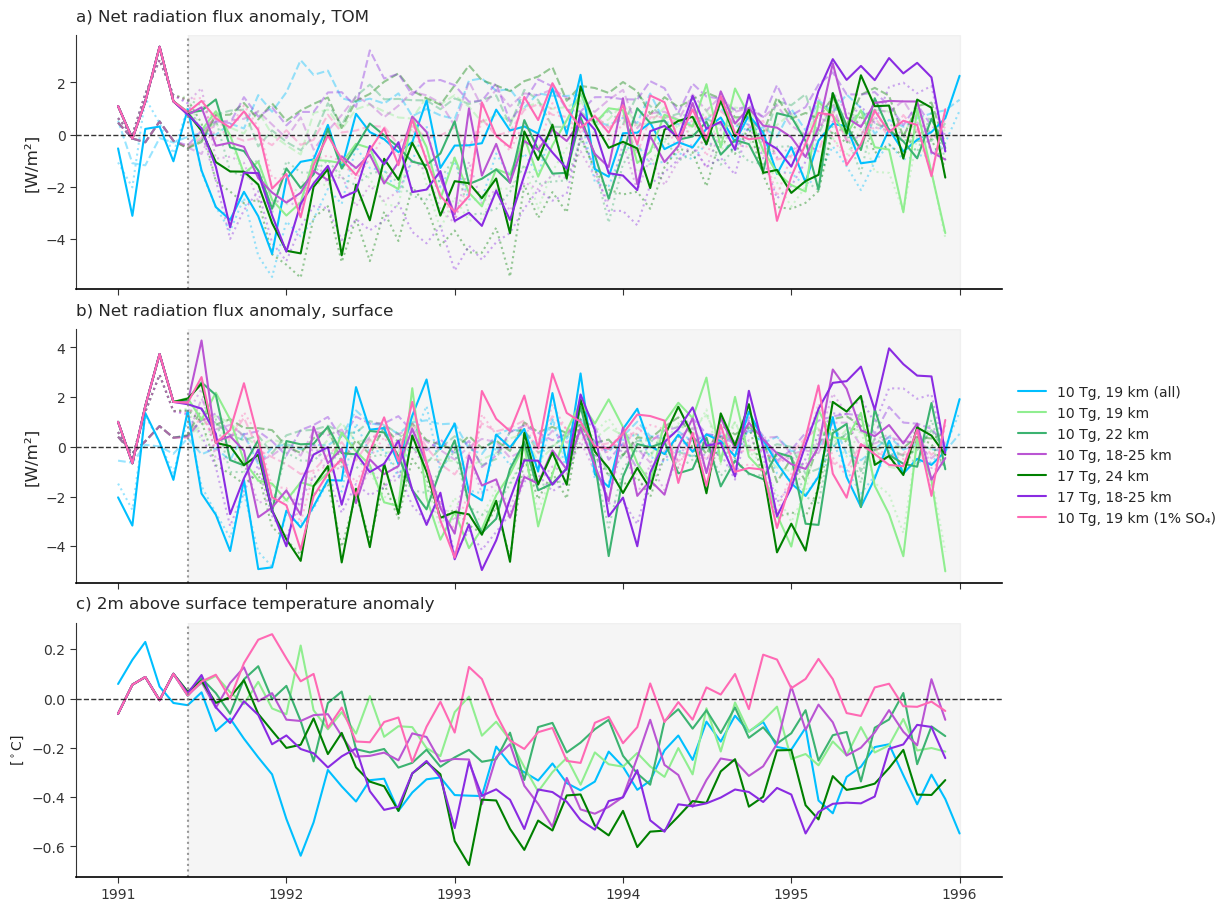

In [30]:
sns.set_style("ticks")
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
start_date    = cftime.DatetimeNoLeap(1991, 1, 1)
end_date      = cftime.DatetimeNoLeap(1996, 1, 1)

xticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in range(1991, 1997)]
xtick_labels = [str(y) for y in range(1991, 1997)]

fig, (ax_top, ax_surf, ax_t) = plt.subplots(3, 1, figsize=(10, 9), sharex=True, constrained_layout=True)

ax_top.plot(netlwtom_anom.time, netlwtom_anom, color = "deepskyblue", lw=1.5, linestyle = "--", alpha=0.4)
ax_top.plot(netlwtom_19_c_anom.time, netlwtom_19_c_anom,color="lightgreen", lw=1.5, linestyle = "--", alpha=0.4)
ax_top.plot(netlwtom_22_anom.time, netlwtom_22_anom,color="mediumseagreen", lw=1.5, linestyle = "--", alpha=0.4)
ax_top.plot(netlwtom_1825_anom.time, netlwtom_1825_anom,color="mediumorchid", lw=1.5, linestyle = "--", alpha=0.4)
ax_top.plot(netlwtom_24_anom.time, netlwtom_24_anom,color="green", lw=1.5, linestyle = "--", alpha=0.4)
ax_top.plot(netlwtom_1825_17tg_anom.time, netlwtom_1825_17tg_anom,color="blueviolet", lw=1.5, linestyle = "--", alpha=0.4)
ax_top.plot(netlwtom_1pr_anom.time, netlwtom_1pr_anom,color="hotpink", lw=1.5, linestyle = "--", alpha=0.4)
#ax_top.plot(netlwtom_1tg_anom.time, netlwtom_1tg_anom,color="orange", lw=1.5, linestyle = "--")
#ax_top.plot(netlwtom_60tg_anom.time, netlwtom_60tg_anom,color="cornflowerblue", lw=1.5, linestyle = "--")
ax_top.set_ylabel("[W/m²]", fontsize=12)

ax_top.plot(netswtom_anom.time, netswtom_anom, color = "deepskyblue", lw=1.5, linestyle = ":", alpha=0.4)
ax_top.plot(netswtom_19_c_anom.time, netswtom_19_c_anom,color="lightgreen", lw=1.5, linestyle = ":", alpha=0.4)
ax_top.plot(netswtom_22_anom.time, netswtom_22_anom,color="mediumseagreen", lw=1.5, linestyle = ":", alpha=0.4)
ax_top.plot(netswtom_1825_anom.time, netswtom_1825_anom,color="mediumorchid", lw=1.5, linestyle = ":", alpha=0.4)
ax_top.plot(netswtom_24_anom.time, netswtom_24_anom,color="green", lw=1.5, linestyle = ":", alpha=0.4)
ax_top.plot(netswtom_1825_17tg_anom.time, netswtom_1825_17tg_anom,color="blueviolet", lw=1.5, linestyle = ":", alpha=0.4)
ax_top.plot(netswtom_1pr_anom.time, netswtom_1pr_anom,color="hotpink", lw=1.5, linestyle = ":", alpha=0.4)
#ax_top.plot(netswtom_1tg_anom.time, netswtom_1tg_anom,color="orange", lw = 1.5, linestyle = ":")
#ax_top.plot(netswtom_60tg_anom.time, netswtom_60tg_anom,color="cornflowerblue", lw=1.5, linestyle = ":")
ax_top.set_ylabel("[W/m²]", fontsize=12)

ax_top.plot(total_tom_19.time, total_tom_19, color = "deepskyblue", lw=1.5)
ax_top.plot(total_tom_19_c.time, total_tom_19_c,color="lightgreen", lw=1.5)
ax_top.plot(total_tom_22.time, total_tom_22,color="mediumseagreen", lw=1.5)
ax_top.plot(total_tom_1825.time, total_tom_1825,color="mediumorchid", lw=1.5)
ax_top.plot(total_tom_24.time, total_tom_24,color="green", lw=1.5)
ax_top.plot(total_tom_1825_17tg.time, total_tom_1825_17tg,color="blueviolet", lw=1.5)
ax_top.plot(total_tom_1pr.time, total_tom_1pr,color="hotpink", lw=1.5)
#ax_top.plot(total_tom_1tg.time, total_tom_1tg,color="orange", lw = 1.5)
#ax_top.plot(total_tom_60tg.time, total_tom_60tg,color="cornflowerblue", lw=1.5)
ax_top.set_ylabel("[W/m²]", fontsize=12)

ax_surf.plot(netlwsurf_anom.time, netlwsurf_anom, color = "deepskyblue", lw=1.5, linestyle = "--", alpha=0.4)
ax_surf.plot(netlwsurf_19_c_anom.time, netlwsurf_19_c_anom,color="lightgreen", lw=1.5, linestyle = "--", alpha=0.4)
ax_surf.plot(netlwsurf_22_anom.time, netlwsurf_22_anom,color="mediumseagreen", lw=1.5, linestyle = "--", alpha=0.4)
ax_surf.plot(netlwsurf_1825_anom.time, netlwsurf_1825_anom,color="mediumorchid", lw=1.5, linestyle = "--", alpha=0.4)
ax_surf.plot(netlwsurf_24_anom.time, netlwsurf_24_anom,color="green", lw=1.5, linestyle = "--", alpha=0.4)
ax_surf.plot(netlwsurf_1825_17tg_anom.time, netlwsurf_1825_17tg_anom,color="blueviolet", lw=1.5, linestyle = "--", alpha=0.4)
ax_surf.plot(netlwsurf_1pr_anom.time, netlwsurf_1pr_anom,color="hotpink", lw=1.5, linestyle = "--", alpha=0.4)
#ax_surf.plot(netlwsurf_1tg_anom.time, netlwsurf_1tg_anom,color="orange", lw=1.5, linestyle = "--")
#ax_surf.plot(netlwsurf_60tg_anom.time, netlwsurf_60tg_anom,color="cornflowerblue", lw=1.5, linestyle = "--")
ax_surf.set_ylabel("[W/m²]", fontsize=12)

ax_surf.plot(netswsurf_anom.time, netswsurf_anom, color = "deepskyblue", lw=1.5, linestyle = ":", alpha=0.4)
ax_surf.plot(netswsurf_19_c_anom.time, netswsurf_19_c_anom,color="lightgreen", lw=1.5, linestyle = ":", alpha=0.4)
ax_surf.plot(netswsurf_22_anom.time, netswsurf_22_anom,color="mediumseagreen", lw=1.5, linestyle = ":", alpha=0.4)
ax_surf.plot(netswsurf_1825_anom.time, netswsurf_1825_anom,color="mediumorchid", lw=1.5, linestyle = ":", alpha=0.4)
ax_surf.plot(netswsurf_24_anom.time, netswsurf_24_anom,color="green", lw=1.5, linestyle = ":", alpha=0.4)
ax_surf.plot(netswsurf_1825_17tg_anom.time, netswsurf_1825_17tg_anom,color="blueviolet", lw=1.5, linestyle = ":", alpha=0.4)
ax_surf.plot(netswsurf_1pr_anom.time, netswsurf_1pr_anom,color="hotpink", lw=1.5, linestyle = ":", alpha=0.4)
#ax_surf.plot(netswsurf_1tg_anom.time, netswsurf_1tg_anom,color="orange", lw = 1.5, linestyle = ":")
#ax_surf.plot(netswsurf_60tg_anom.time, netswsurf_60tg_anom,color="cornflowerblue", lw=1.5, linestyle = ":")
ax_surf.set_ylabel("[W/m²]", fontsize=12)

ax_surf.plot(total_surf_19.time, total_surf_19, color = "deepskyblue", lw=1.5)
ax_surf.plot(total_surf_19_c.time, total_surf_19_c,color="lightgreen", lw=1.5)
ax_surf.plot(total_surf_22.time, total_surf_22,color="mediumseagreen", lw=1.5)
ax_surf.plot(total_surf_1825.time, total_surf_1825,color="mediumorchid", lw=1.5)
ax_surf.plot(total_surf_24.time, total_surf_24,color="green", lw=1.5)
ax_surf.plot(total_surf_1825_17tg.time, total_surf_1825_17tg,color="blueviolet", lw=1.5)
ax_surf.plot(total_surf_1pr.time, total_surf_1pr,color="hotpink", lw=1.5)
#ax_surf.plot(total_surf_1tg.time, total_surf_1tg,color="orange", lw = 1.5)
#ax_surf.plot(total_surf_60tg.time, total_surf_60tg,color="cornflowerblue", lw=1.5)
ax_surf.set_ylabel("[W/m²]", fontsize=12)

ax_t.plot(temp_19_anom.time, temp_19_anom, color="deepskyblue", label = "10 Tg, 19 km (all)", lw =1.5)
ax_t.plot(t_anom_19_c.time, t_anom_19_c,color="lightgreen", label="10 Tg, 19 km", lw=1.5)
ax_t.plot(t_anom_22.time, t_anom_22,color="mediumseagreen", label="10 Tg, 22 km",lw=1.5)
ax_t.plot(t_anom_1825.time, t_anom_1825,color="mediumorchid", label="10 Tg, 18-25 km", lw=1.5)
ax_t.plot(t_anom_24.time, t_anom_24,color="green",label="17 Tg, 24 km", lw=1.5)
ax_t.plot(t_anom_1825_17tg.time, t_anom_1825_17tg,color="blueviolet", label="17 Tg, 18-25 km", lw=1.5)
ax_t.plot(t_anom_1pr.time, t_anom_1pr,color="hotpink", label="10 Tg, 19 km (1% SO₄)", lw=1.5)
#ax_t.plot(t_anom_1tg.time, t_anom_1tg, color="orange", label="1 Tg, 19 km", lw=1.5)
#ax_t.plot(t_anom_60tg.time, t_anom_60tg,color="cornflowerblue", label="60 Tg, 19 km", lw=1.5)
ax_t.set_ylabel("[$^\circ$C]")

axes = [ax_top, ax_surf, ax_t]
titles = ["a) Net radiation flux anomaly, TOM", "b) Net radiation flux anomaly, surface", "c) 2m above surface temperature anomaly"]

for i, ax in enumerate(axes):
    ax.axhline(0, color="black", lw=1.0, ls='--', alpha=0.8)
    ax.axvline(eruption_date, color='gray', ls = ":", alpha=0.8)
    ax.axvspan(eruption_date, cftime.DatetimeNoLeap(1996, 1, 1), color='gray', alpha=0.08, zorder=0)
    ax.tick_params(direction='out', length=4)
    ax.set_title(titles[i], loc='left', fontsize=12, pad=10)
    
    sns.despine(ax=ax)

for ax in [ax_top, ax_surf, ax_t]:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.2)


fig.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=10
)

plt.show()

<>:48: SyntaxWarning: invalid escape sequence '\c'
<>:48: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2551705/246367415.py:48: SyntaxWarning: invalid escape sequence '\c'
  ax_t.set_ylabel("[$^\circ$C]")


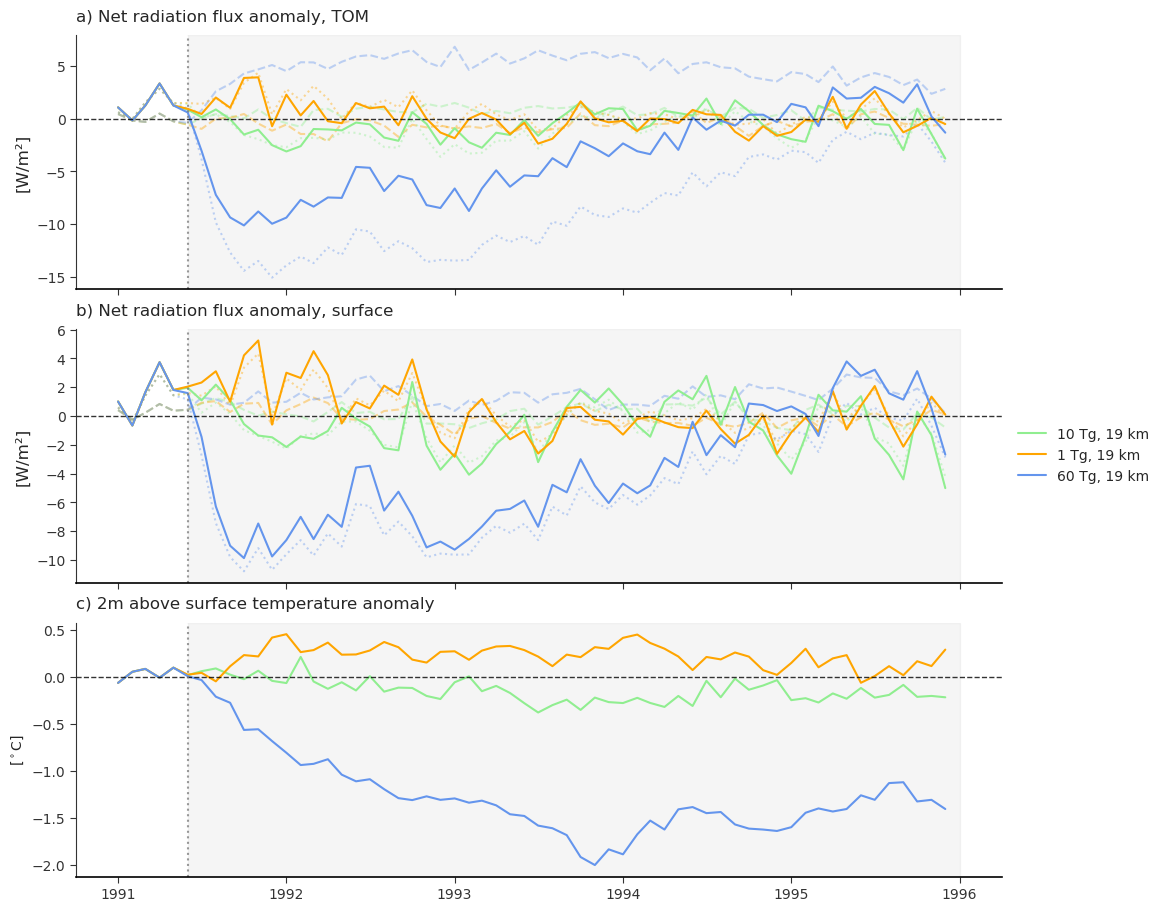

In [31]:
sns.set_style("ticks")
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
start_date    = cftime.DatetimeNoLeap(1991, 1, 1)
end_date      = cftime.DatetimeNoLeap(1996, 1, 1)

xticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in range(1991, 1997)]
xtick_labels = [str(y) for y in range(1991, 1997)]

fig, (ax_top, ax_surf, ax_t) = plt.subplots(3, 1, figsize=(10, 9), sharex=True, constrained_layout=True)

ax_top.plot(netlwtom_19_c_anom.time, netlwtom_19_c_anom,color="lightgreen", lw=1.5, linestyle = "--", alpha=0.4)
ax_top.plot(netlwtom_1tg_anom.time, netlwtom_1tg_anom,color="orange", lw=1.5, linestyle = "--", alpha=0.4)
ax_top.plot(netlwtom_60tg_anom.time, netlwtom_60tg_anom,color="cornflowerblue", lw=1.5, linestyle = "--", alpha=0.4)
ax_top.set_ylabel("[W/m²]", fontsize=12)

ax_top.plot(netswtom_19_c_anom.time, netswtom_19_c_anom,color="lightgreen", lw=1.5, linestyle = ":", alpha=0.4)
ax_top.plot(netswtom_1tg_anom.time, netswtom_1tg_anom,color="orange", lw = 1.5, linestyle = ":", alpha=0.4)
ax_top.plot(netswtom_60tg_anom.time, netswtom_60tg_anom,color="cornflowerblue", lw=1.5, linestyle = ":", alpha=0.4)
ax_top.set_ylabel("[W/m²]", fontsize=12)

ax_top.plot(total_tom_19_c.time, total_tom_19_c,color="lightgreen", lw=1.5)
ax_top.plot(total_tom_1tg.time, total_tom_1tg,color="orange", lw = 1.5)
ax_top.plot(total_tom_60tg.time, total_tom_60tg,color="cornflowerblue", lw=1.5)
ax_top.set_ylabel("[W/m²]", fontsize=12)

ax_surf.plot(netlwsurf_19_c_anom.time, netlwsurf_19_c_anom,color="lightgreen", lw=1.5, linestyle = "--", alpha=0.4)
ax_surf.plot(netlwsurf_1tg_anom.time, netlwsurf_1tg_anom,color="orange", lw=1.5, linestyle = "--", alpha=0.4)
ax_surf.plot(netlwsurf_60tg_anom.time, netlwsurf_60tg_anom,color="cornflowerblue", lw=1.5, linestyle = "--", alpha=0.4)
ax_surf.set_ylabel("[W/m²]", fontsize=12)

ax_surf.plot(netswsurf_19_c_anom.time, netswsurf_19_c_anom,color="lightgreen", lw=1.5, linestyle = ":", alpha=0.4)
ax_surf.plot(netswsurf_1tg_anom.time, netswsurf_1tg_anom,color="orange", lw = 1.5, linestyle = ":", alpha=0.4)
ax_surf.plot(netswsurf_60tg_anom.time, netswsurf_60tg_anom,color="cornflowerblue", lw=1.5, linestyle = ":", alpha=0.4)
ax_surf.set_ylabel("[W/m²]", fontsize=12)

ax_surf.plot(total_surf_19_c.time, total_surf_19_c,color="lightgreen", lw=1.5)
ax_surf.plot(total_surf_1tg.time, total_surf_1tg,color="orange", lw = 1.5)
ax_surf.plot(total_surf_60tg.time, total_surf_60tg,color="cornflowerblue", lw=1.5)
ax_surf.set_ylabel("[W/m²]", fontsize=12)

ax_t.plot(t_anom_19_c.time, t_anom_19_c,color="lightgreen", label="10 Tg, 19 km", lw=1.5)
ax_t.plot(t_anom_1tg.time, t_anom_1tg, color="orange", label="1 Tg, 19 km", lw=1.5)
ax_t.plot(t_anom_60tg.time, t_anom_60tg,color="cornflowerblue", label="60 Tg, 19 km", lw=1.5)
ax_t.set_ylabel("[$^\circ$C]")

axes = [ax_top, ax_surf, ax_t]
titles = ["a) Net radiation flux anomaly, TOM", "b) Net radiation flux anomaly, surface", "c) 2m above surface temperature anomaly"]

for i, ax in enumerate(axes):
    ax.axhline(0, color="black", lw=1.0, ls='--', alpha=0.8)
    ax.axvline(eruption_date, color='gray', ls = ":", alpha=0.8)
    ax.axvspan(eruption_date, cftime.DatetimeNoLeap(1996, 1, 1), color='gray', alpha=0.08, zorder=0)
    ax.tick_params(direction='out', length=4)
    ax.set_title(titles[i], loc='left', fontsize=12, pad=10)
    
    sns.despine(ax=ax)

for ax in [ax_top, ax_surf, ax_t]:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.2)


fig.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=10
)

plt.show()

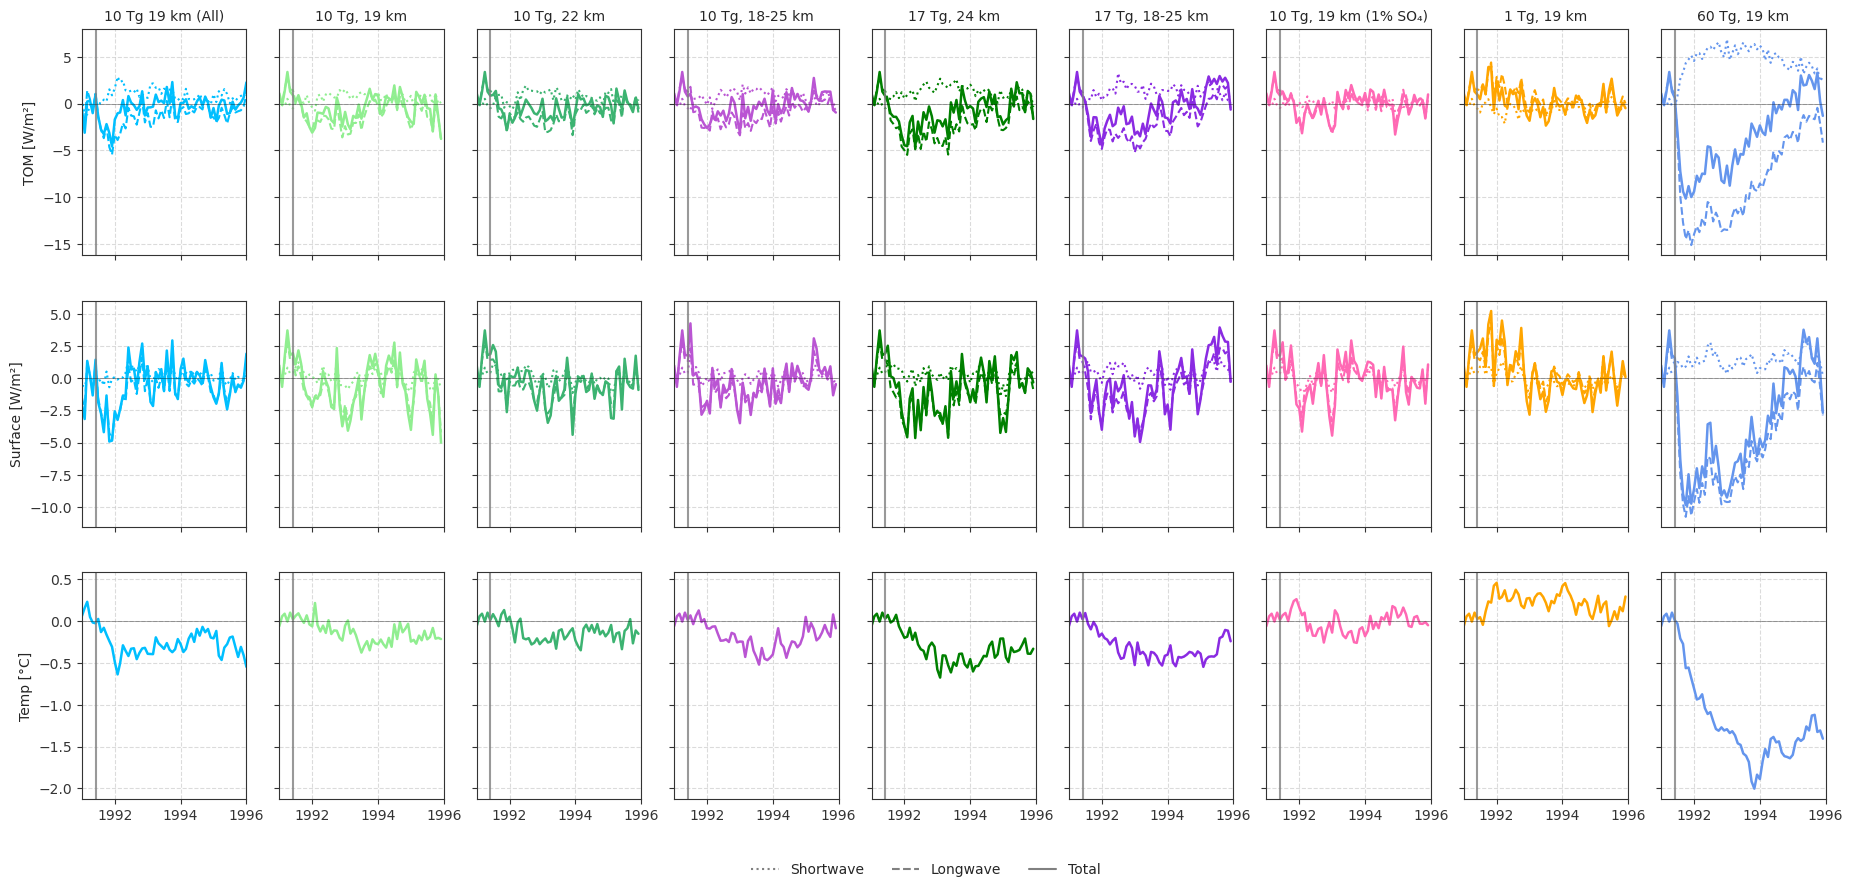

In [36]:
experiments = [
    (netswtom_anom, netlwtom_anom, total_tom_19, netswsurf_anom, netlwsurf_anom, total_surf_19, temp_19_anom, "deepskyblue", "10 Tg 19 km (All)"),
    (netswtom_19_c_anom, netlwtom_19_c_anom, total_tom_19_c, netswsurf_19_c_anom, netlwsurf_19_c_anom, total_surf_19_c, t_anom_19_c, "lightgreen", "10 Tg, 19 km"),
    (netswtom_22_anom, netlwtom_22_anom, total_tom_22,  netswsurf_22_anom, netlwsurf_22_anom, total_surf_22, t_anom_22, "mediumseagreen", "10 Tg, 22 km"),
    (netswtom_1825_anom, netlwtom_1825_anom, total_tom_1825, netswsurf_1825_anom, netlwsurf_1825_anom, total_surf_1825, t_anom_1825, "mediumorchid", "10 Tg, 18-25 km"),
    (netswtom_24_anom, netlwtom_24_anom, total_tom_24, netswsurf_24_anom, netlwsurf_24_anom, total_surf_24, t_anom_24, "green", "17 Tg, 24 km"),
    (netswtom_1825_17tg_anom, netlwtom_1825_17tg_anom, total_tom_1825_17tg, netswsurf_1825_17tg_anom, netlwsurf_1825_17tg_anom, total_surf_1825_17tg, t_anom_1825_17tg, "blueviolet", "17 Tg, 18-25 km"),
    (netswtom_1pr_anom, netlwtom_1pr_anom, total_tom_1pr, netswsurf_1pr_anom, netlwsurf_1pr_anom, total_surf_1pr, t_anom_1pr, "hotpink", "10 Tg, 19 km (1% SO₄)"),
    (netswtom_1tg_anom, netlwtom_1tg_anom, total_tom_1tg, netswsurf_1tg_anom, netlwsurf_1tg_anom, total_surf_1tg, t_anom_1tg, "orange", "1 Tg, 19 km"),
    (netswtom_60tg_anom, netlwtom_60tg_anom, total_tom_60tg, netswsurf_60tg_anom, netlwsurf_60tg_anom, total_surf_60tg, t_anom_60tg, "cornflowerblue", "60 Tg, 19 km")
]

num_exps = len(experiments)

fig, axes = plt.subplots(3, num_exps, figsize=(num_exps * 2.5, 10), sharex=True, sharey='row')

for i, (sw_t, lw_t, tot_t, sw_s, lw_s, tot_s, tmp, color, name) in enumerate(experiments):
    ax_tom = axes[0, i]
    sw_t.plot(ax=ax_tom, color=color, ls="--")
    lw_t.plot(ax=ax_tom, color=color, ls=":")
    tot_t.plot(ax=ax_tom, color=color, ls="-", lw=1.8)
    
    ax_tom.set_title(name, fontsize=10)
    
    ax_surf = axes[1, i]
    sw_s.plot(ax=ax_surf, color=color, ls="--")
    lw_s.plot(ax=ax_surf, color=color, ls=":")
    tot_s.plot(ax=ax_surf, color=color, ls="-", lw=1.8)
    ax_surf.set_title("") 
    
    ax_temp = axes[2, i]
    tmp.plot(ax=ax_temp, color=color, lw=1.8)
    ax_temp.set_title("")

    for ax in [ax_tom, ax_surf, ax_temp]:
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.axvline(x=eruption_date, color="gray", linestyle="-", lw=1.5, alpha=0.8)
        
        ax.axhline(0, color="black", lw=0.6, alpha=0.4)
        ax.set_xlabel("")
        ax.set_ylabel("") 
        ax.set_xlim(start_date, end_date)

axes[0, 0].set_ylabel("TOM [W/m²]", fontsize=10)
axes[1, 0].set_ylabel("Surface [W/m²]", fontsize=10)
axes[2, 0].set_ylabel("Temp [°C]", fontsize=10)

custom_lines = [Line2D([0], [0], color='gray', ls=':'),
                Line2D([0], [0], color='gray', ls='--'),
                Line2D([0], [0], color='gray', ls='-')]
fig.legend(custom_lines, ['Shortwave', 'Longwave', 'Total'], 
           loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.02))

plt.show()